# Exploratory Data Analysis: Credit Scoring

Цель notebook — проверить качество данных, изучить баланс целевого класса и связи признаков с дефолтом. Обучение моделей вынесено в `train_models.py`, чтобы EDA не дублировал основной ML-пайплайн.

Целевая переменная `loan_status`:
- `0` — дефольта нет;
- `1` — дефольт.

> Источник и условия сбора датасета не задокументированы, поэтому результаты нельзя без дополнительной проверки переносить на реальную кредитную политику.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

DATA_PATH = Path("loan_data.csv")
TARGET = "loan_status"
RANDOM_STATE = 42

## 1. Загрузка и схема данны

In [2]:
data = pd.read_csv(DATA_PATH)
print(f"Rows: {len(data):,}")
print(f"Columns: {data.shape[1]}")
display(data.head())

schema = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "unique_values": data.nunique(dropna=False),
    "missing": data.isna().sum(),
})
display(schema)

Rows: 45,000
Columns: 14


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


,dtype,unique_values,missing
person_age,float64,60,0
person_gender,object,2,0
person_education,object,5,0
person_income,float64,33989,0
person_emp_exp,int64,63,0
person_home_ownership,object,4,0
loan_amnt,float64,4483,0
loan_intent,object,6,0
loan_int_rate,float64,1302,0
loan_percent_income,float64,64,0


## 2. Качество данны

Проверяем пропуски, полные дубликаты, допустимые значения target и физически невозможные возрасты. Правило `18 <= person_age <= 100` задано до обучения и совпадает с правилом в `train_models.py`.

In [3]:
invalid_age = ~data["person_age"].between(18, 100, inclusive="both")
quality_report = pd.Series({
    "rows": len(data),
    "missing_values": int(data.isna().sum().sum()),
    "duplicate_rows": int(data.duplicated().sum()),
    "invalid_target_values": int((~data[TARGET].isin([0, 1])).sum()),
    "invalid_age_rows": int(invalid_age.sum()),
}, name="value").to_frame()
display(quality_report)

if invalid_age.any():
    display(data.loc[invalid_age, ["person_age", TARGET]].sort_values("person_age"))

clean_data = data.loc[~invalid_age].copy().reset_index(drop=True)
print(f"Rows after the age rule: {len(clean_data):,}")

,value
rows,45000
missing_values,0
duplicate_rows,0
invalid_target_values,0
invalid_age_rows,7


,person_age,loan_status
38113,109.0,0
37930,116.0,0
747,123.0,0
575,123.0,0
81,144.0,0
183,144.0,0
32297,144.0,0


Rows after the age rule: 44,993


## 3. Баланс целевого класса

Доля дефольтов важна для выбора метрик и схемы разбиения. В обучении используется stratified split, а качество оценивается не только accuracy, но и ROC-AUC, Average Precision и бизнес-метриками.

,count,share
loan_status,,
0,34993,77.77%
1,10000,22.23%


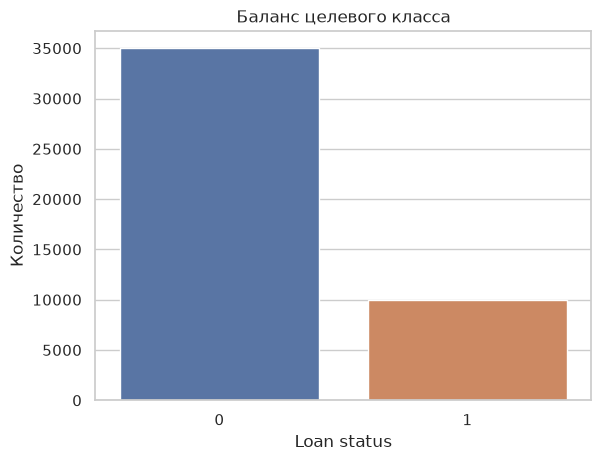

In [4]:
target_summary = (
    clean_data[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET)
    .to_frame("count")
)
target_summary["share"] = target_summary["count"] / len(clean_data)
display(target_summary.style.format({"share": "{:.2%}"}))

ax = sns.countplot(data=clean_data, x=TARGET, hue=TARGET, legend=False)
ax.set(title="Баланс целевого класса", xlabel="Loan status", ylabel="Количество")
plt.show()

## 4. Числовые признаки

В таблице добавлены квантили, чтобы отделить типичный диапазон от редких крайних значений. Обрезка по 99-му процентилю ниже используется **только для масштаба графиков** и не изменяет данные для модели.

,count,mean,std,min,1%,5%,50%,95%,99%,max
person_age,44993.0,27.748428,5.909737,20.00,21.00,22.00,26.00,39.00,48.00,94.00
person_income,44993.0,79908.447581,63322.132349,8000.00,17875.60,28364.60,67046.00,166693.80,271266.96,2448661.00
person_emp_exp,44993.0,5.394528,5.927159,0.00,0.00,0.00,4.00,17.00,26.00,76.00
loan_amnt,44993.0,9583.176761,6314.802655,500.00,1137.96,2000.00,8000.00,24000.00,28392.72,35000.00
loan_int_rate,44993.0,11.006448,2.978985,5.42,5.42,6.17,11.01,16.00,18.25,20.00
loan_percent_income,44993.0,0.139736,0.087207,0.00,0.02,0.03,0.12,0.31,0.40,0.66
cb_person_cred_hist_length,44993.0,5.866557,3.877167,2.00,2.00,2.00,4.00,14.00,17.00,30.00
credit_score,44993.0,632.585713,50.402411,390.00,497.00,539.00,640.00,703.00,724.00,784.00


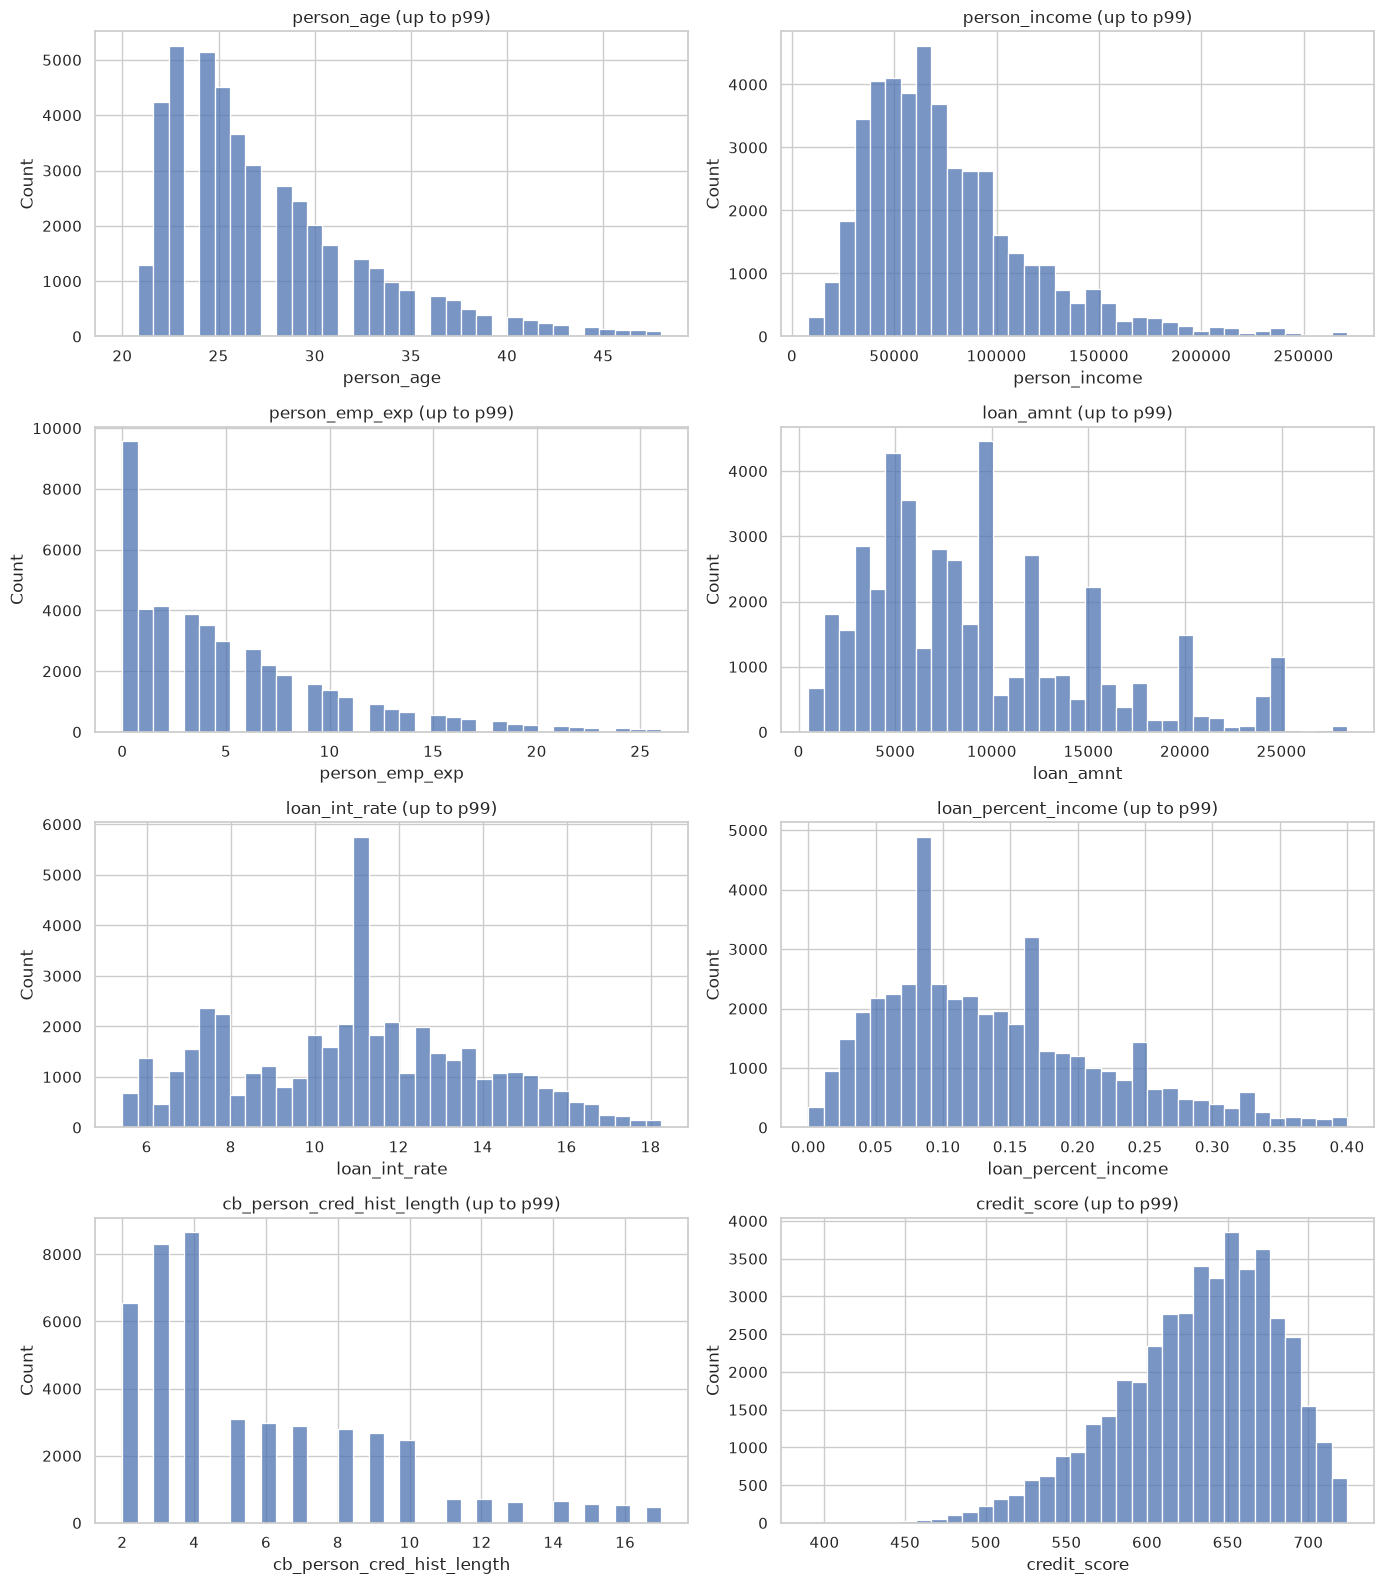

In [5]:
numeric_features = clean_data.select_dtypes(include="number").columns.drop(TARGET).tolist()
numeric_summary = clean_data[numeric_features].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).T
display(numeric_summary)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for feature, ax in zip(numeric_features, axes.flat):
    upper = clean_data[feature].quantile(0.99)
    sns.histplot(clean_data.loc[clean_data[feature] <= upper, feature], bins=35, ax=ax)
    ax.set_title(f"{feature} (up to p99)")
plt.tight_layout()
plt.show()

## 5. Категориальные признаки и default rate

Для каждой категории считаем число наблюдений и среднюю долю дефольтов. Это описательный анализ: он не доказывает причинно-следственную связь.

,feature,category,count,default_rate
0,person_gender,female,20157,22.25%
1,person_gender,male,24836,22.21%
2,person_education,Associate,12026,22.04%
3,person_education,Bachelor,13396,22.53%
4,person_education,Doctorate,621,22.87%
5,person_education,High School,11970,22.31%
6,person_education,Master,6980,21.76%
7,person_home_ownership,MORTGAGE,18485,11.60%
8,person_home_ownership,OTHER,117,33.33%
9,person_home_ownership,OWN,2951,7.52%


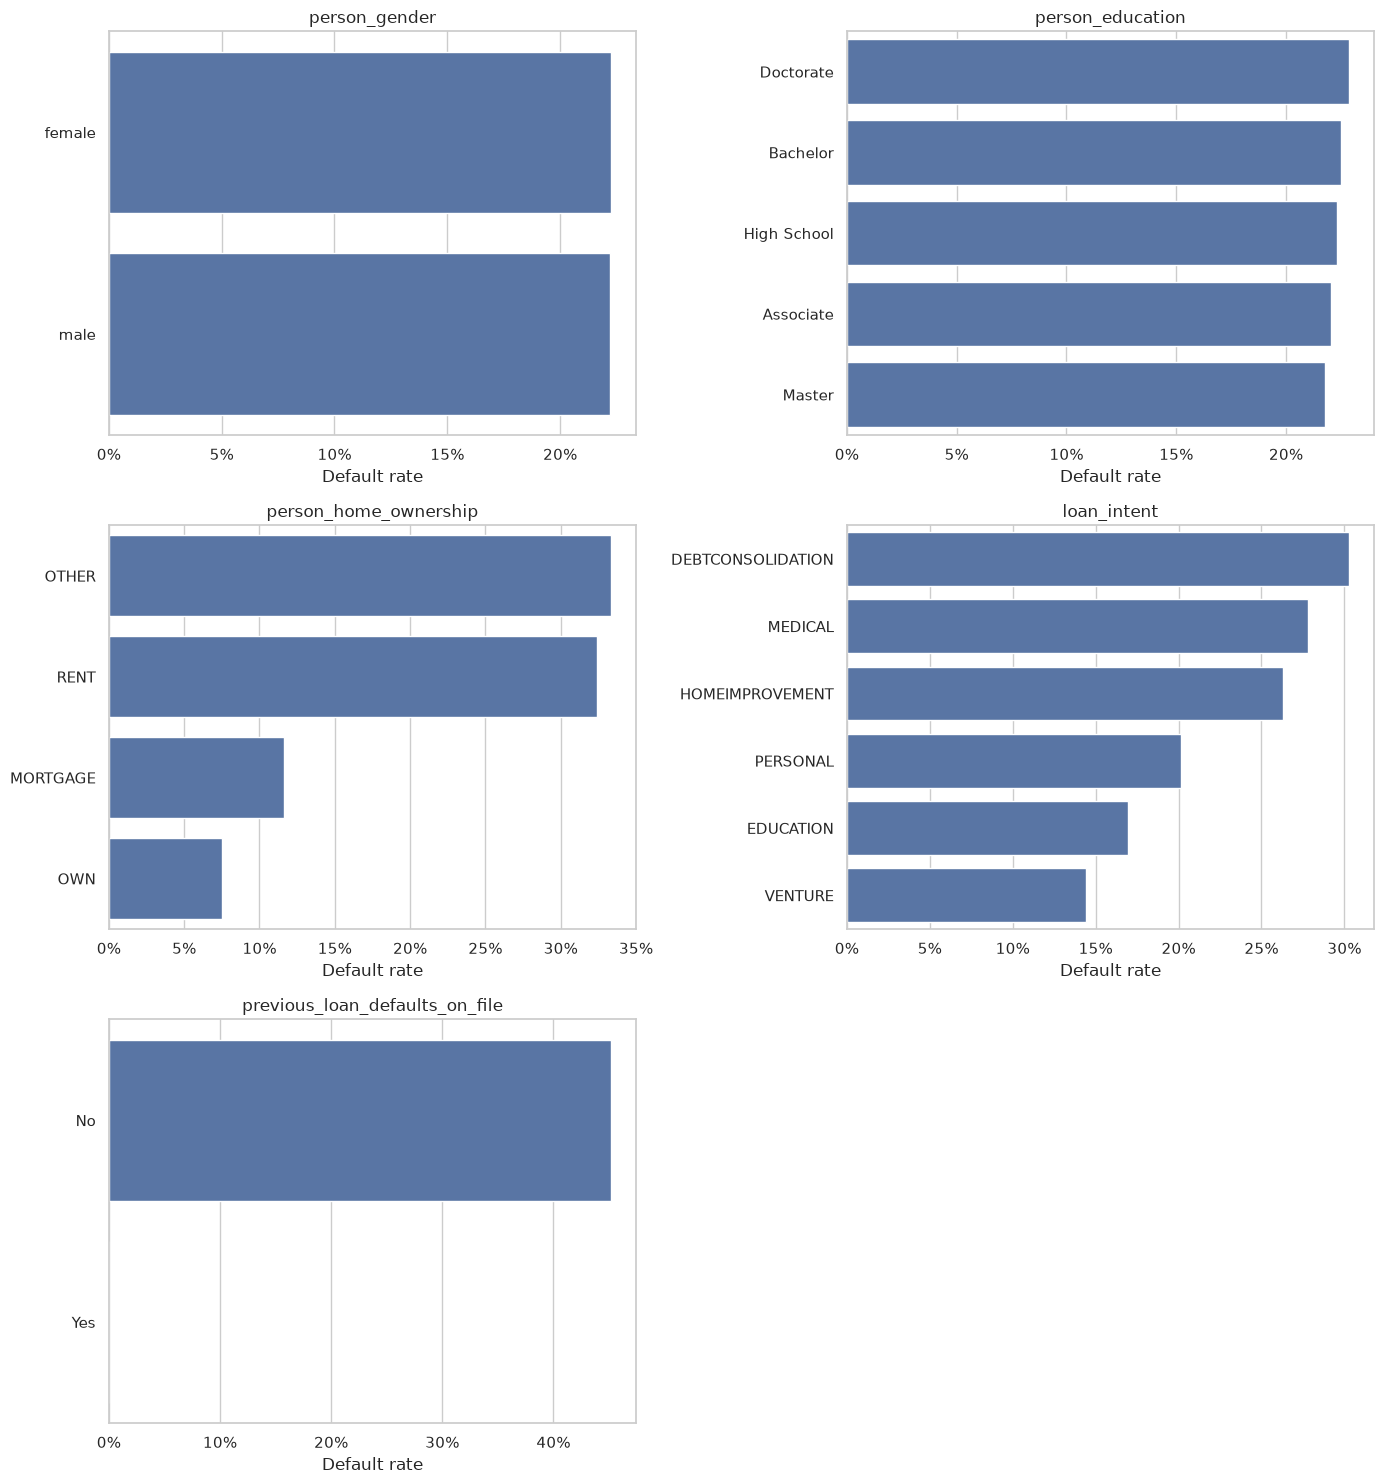

In [6]:
categorical_features = clean_data.select_dtypes(exclude="number").columns.tolist()
category_tables = []
for feature in categorical_features:
    table = (
        clean_data.groupby(feature, dropna=False)[TARGET]
        .agg(count="size", default_rate="mean")
        .reset_index()
        .rename(columns={feature: "category"})
    )
    table.insert(0, "feature", feature)
    category_tables.append(table)

categorical_summary = pd.concat(category_tables, ignore_index=True)
display(categorical_summary.style.format({"default_rate": "{:.2%}"}))

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for feature, ax in zip(categorical_features, axes.flat):
    plot_data = categorical_summary.loc[
        categorical_summary["feature"] == feature
    ].sort_values("default_rate", ascending=False)
    sns.barplot(data=plot_data, x="default_rate", y="category", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("Default rate")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
for ax in axes.flat[len(categorical_features):]:
    ax.remove()
plt.tight_layout()
plt.show()

## 6. Числовые связи с целевой переменной

Корреляция показывает только линейную связь. Слабая корреляция не означает, что признак бесполезен для нелинейной модели.

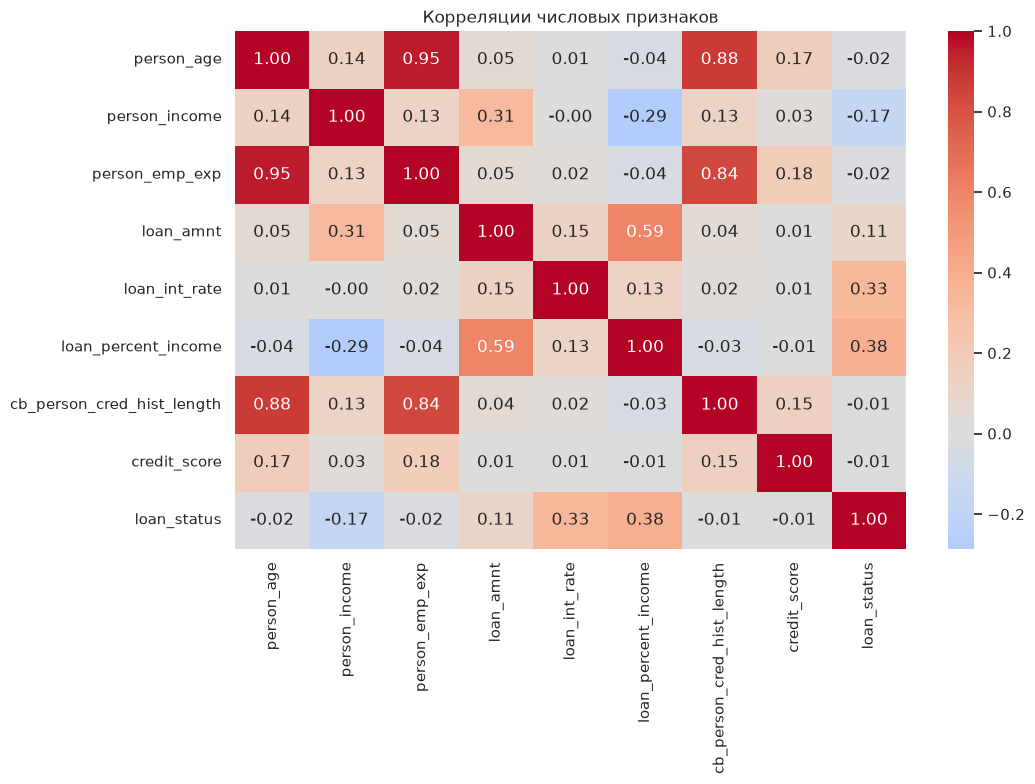

,correlation_with_target
loan_percent_income,0.384873
loan_int_rate,0.332046
person_income,-0.169034
loan_amnt,0.107725
person_age,-0.020545
person_emp_exp,-0.019529
cb_person_cred_hist_length,-0.014733
credit_score,-0.007409


In [7]:
correlation = clean_data.select_dtypes(include="number").corr()
plt.figure(figsize=(11, 8))
sns.heatmap(correlation, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Корреляции числовых признаков")
plt.tight_layout()
plt.show()

target_correlations = (
    correlation[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .to_frame("correlation_with_target")
)
display(target_correlations)

## 7. Выводы

- После применения заранее заданного правила возраста в выборке остаётся 44 993 наблюдения.
- Пропусков и полных дубликатов в текущей версии данных нет; импьютеры в ML-пайплайне оставлены для устойчивости к новым данным.
- Целевой класс несбалансирован, поэтому при разбиении используется стратификация, а accuracy не является единственной метрикой.
- Разные группы клиентов имеют разный наблюдаемый default rate; эти связи нельзя трактовать как причинные.
- Признаки пола и образования требуют отдельной fairness-проверки перед любым реальным использованием.
- Воспроизводимое обучение, валидация, выбор бизнес-порога и тестовая оценка реализованы в `train_models.py`.